#Visualização dos Dados em gráficos.

Gráficos interessantes:

Tempo de execução x Load (Varias linhas de Threads)

Speedup x Load (Varias linhas de Threads)

Eficiencia x Load (Varias linhas de Threads)

^^^^ mas x Threads (para varios Loads)


Analise de dependencia (R, C, A, N)

Analise de Caso Real (R=10, C=1000, A=10000, N=10)


In [801]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [802]:
def plot_Time_Load(Cases_Seq, Cases_Par, Tmax, Title="Tempo de Exec X Carga", style_log=False, save_fig=False):
    fig, ax = plt.subplots()
    ax.grid(True, linestyle='--', color='gray', alpha=0.7)
    ax.errorbar(Cases_Seq[:,0],Cases_Seq[:,1],Cases_Seq[:,2], marker="o", ms=5,label=f"Seq")
    for T in range(1,Tmax+1):
        ax.errorbar(Cases_Par[T,:,0],Cases_Par[T,:,1],Cases_Par[T,:,2], marker="o", ms=5, label=f"{T}")
    ax.set_xlabel("Carga")
    ax.set_ylabel("T(s)")
    if(style_log):
        ax.set_xscale("log")
        ax.set_yscale("log")
    plt.legend(title="Sequencial e Threads", ncols=2, fontsize="small")
    plt.title(Title)
    if(save_fig):
        plt.savefig(f"Figs/{Title}.png")
    plt.show()

def plot_Speedup_Load(Speedup_Par, Tmax, Title="Speedup X Carga", style_log=False, save_fig=False):
    fig, ax = plt.subplots()
    ax.grid(True, linestyle='--', color='gray', alpha=0.7)
    for T in range(1,Tmax+1):
        ax.plot(Speedup_Par[T,:,0],Speedup_Par[T,:,1], marker="o", ms=5, label=f"{T}")
    ax.set_xlabel("Carga")
    ax.set_ylabel("Sp")
    if(style_log):
        ax.set_xscale("log")
        ax.set_yscale("log")
    plt.legend(title="Threads", ncols=2, fontsize="small")
    plt.title(Title)
    if(save_fig):
        plt.savefig(f"Figs/{Title}.png")
    plt.show()

def plot_Eficiency_Load(Eficiency_Par, Tmax, Title="Eficiencia X Carga", style_log=False, save_fig=False):
    fig, ax = plt.subplots()
    ax.grid(True, linestyle='--', color='gray', alpha=0.7)
    for T in range(1,Tmax+1):
        ax.plot(Eficiency_Par[T,:,0],Eficiency_Par[T,:,1], marker="o", ms=5, label=f"{T}")
    ax.set_xlabel("Carga")
    ax.set_ylabel("Ep")
    if(style_log):
        ax.set_xscale("log")
        ax.set_yscale("log")
    plt.legend(title="Threads", ncols=2, fontsize="small")
    plt.title(Title)
    if(save_fig):
        plt.savefig(f"Figs/{Title}.png")
    plt.show()

def plot_Time_Threads(Cases_Par_T, Loads, Title="Tempo de Exec X Threads", style_log=False, save_fig=False):
    fig, ax = plt.subplots()
    ax.grid(True, linestyle='--', color='gray', alpha=0.7)
    for i in range(0,len(Loads)):
        ax.errorbar(Cases_Par_T[i,:,0],Cases_Par_T[i,:,1],Cases_Par_T[i,:,2], marker="o", ms=5, label=f"{Loads[i][0]:.2e}")
    ax.set_xlabel("Threads")
    ax.set_ylabel("T(s)")
    if(style_log):
        ax.set_xscale("log")
        ax.set_yscale("log")
    plt.legend(title="Carga", ncols=2, fontsize="small")
    plt.title(Title)
    if(save_fig):
        plt.savefig(f"Figs/{Title}.png")
    plt.show()

def plot_Speedup_Threads(Speedup_Par_T, Loads, Tmax, Title="Speedup X Threads", style_log=False, save_fig=False):
    x=np.array([1,Tmax])
    y=np.array([1,Tmax])
    fig, ax = plt.subplots()
    ax.grid(True, linestyle='--', color='gray', alpha=0.7)
    for i in range(0,len(Loads)):
        ax.plot(Speedup_Par_T[i,:,0],Speedup_Par_T[i,:,1], marker="o", ms=5, label=f"{Loads[i][0]:.2e}")
    ax.set_xlabel("Threads")
    ax.set_ylabel("Sp")
    if(style_log):
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.plot(x,y,'--',color="tab:gray",label="Linear")
    plt.legend(title="Carga", ncols=2, fontsize="small")
    plt.title(Title)
    if(save_fig):
        plt.savefig(f"Figs/{Title}.png")
    plt.show()

def plot_Eficiency_Threads(Eficiency_Par_T, Loads, Title="Eficiencia X Threads", style_log=False, save_fig=False):
    fig, ax = plt.subplots()
    ax.grid(True, linestyle='--', color='gray', alpha=0.7)
    for i in range(0,len(Loads)):
        ax.plot(Eficiency_Par_T[i,:,0],Eficiency_Par_T[i,:,1], marker="o", ms=5, label=f"{Loads[i][0]:.2e}")
    ax.set_xlabel("Threads")
    ax.set_ylabel("Ep")
    if(style_log):
        ax.set_xscale("log")
        ax.set_yscale("log")
    plt.legend(title="Carga", ncols=2, fontsize="small")
    plt.title(Title)
    if(save_fig):
        plt.savefig(f"Figs/{Title}.png")
    plt.show()


def plot_Time_Threads_Isolation(Cases_Par_T, Loads, labels, markers, Title="Tempo de Exec X Threads",style_log=False, save_fig=False):
    fig, ax = plt.subplots()
    ax.grid(True, linestyle='--', color='gray', alpha=0.7)
    for i in range(0,Cases_Par_T.shape[0]):
        for j in range(0,Cases_Par_T.shape[1]):
            ax.errorbar(Cases_Par_T[i,j,:,0],Cases_Par_T[i,j,:,1],Cases_Par_T[i,j,:,2], marker=markers[i], ms=5, label=labels[i][j])
    ax.set_xlabel("Threads")
    ax.set_ylabel("T(s)")
    if(style_log):
        ax.set_xscale("log")
        ax.set_yscale("log")
    plt.legend(title=f"Carga {Loads[0][0]:.2e}", ncols=2, fontsize="small")
    plt.title(Title)
    if(save_fig):
        plt.savefig(f"Figs/{Title}.png")
    plt.show()

def plot_Speedup_Threads_Isolation(Speedup_Par_T, Loads, Tmax, labels, markers, Title="Speedup X Threads",style_log=False, save_fig=False):
    x=np.array([1,Tmax])
    y=np.array([1,Tmax])
    fig, ax = plt.subplots()
    ax.grid(True, linestyle='--', color='gray', alpha=0.7)
    for i in range(0,Speedup_Par_T.shape[0]):
        for j in range(0,Speedup_Par_T.shape[1]):
            ax.plot(Speedup_Par_T[i,j,:,0],Speedup_Par_T[i,j,:,1], marker=markers[i], ms=5, label=labels[i][j])
    ax.plot(x,y,'--',color="tab:gray", label="Linear")
    ax.set_xlabel("Threads")
    ax.set_ylabel("Sp")
    if(style_log):
        ax.set_xscale("log")
        ax.set_yscale("log")
    plt.legend(title=f"Carga {Loads[0][0]:.2e}", ncols=2, fontsize="small")
    plt.title(Title)
    if(save_fig):
        plt.savefig(f"Figs/{Title}.png")
    plt.show()

def plot_Eficiency_Threads_Isolation(Eficiency_Par_T, Loads, labels, markers, Title="Eficiencia X Threads",style_log=False, save_fig=False):
    fig, ax = plt.subplots()
    ax.grid(True, linestyle='--', color='gray', alpha=0.7)
    for i in range(0,Eficiency_Par_T.shape[0]):
        for j in range(0,Eficiency_Par_T.shape[1]):
            ax.plot(Eficiency_Par_T[i,j,:,0],Eficiency_Par_T[i,j,:,1], marker=markers[i], ms=5, label=labels[i][j])
    ax.set_xlabel("Threads")
    ax.set_ylabel("Ep")
    if(style_log):
        ax.set_xscale("log")
        ax.set_yscale("log")
    plt.legend(title=f"Carga {Loads[0][0]:.2e}", ncols=2, fontsize="small")
    plt.title(Title)
    if(save_fig):
        plt.savefig(f"Figs/{Title}.png")
    plt.show()

In [803]:
csv_caminho = 'resultados.csv'
Tmax=10

def Work_Data(CSV_Path, Tmax, seed):
    df = pd.read_csv(CSV_Path)

    dfA = df[(df["seed"]==seed)]
    dfA1 = dfA[dfA["T"]==1]

    rowcount=dfA1.shape[0]

    Casos_Par=np.zeros((Tmax+1,rowcount,3))
    Speedup_Par=np.zeros((Tmax+1,rowcount,2))
    Eficiencia_Par=np.zeros((Tmax+1,rowcount,2))

    Casos_Par_T=np.zeros((rowcount,Tmax,3))
    Speedup_Par_T=np.zeros((rowcount,Tmax,2))
    Eficiencia_Par_T=np.zeros((rowcount,Tmax,2))
    Totais=dfA1[["Total"]].to_numpy()


    for T in range (1,Tmax+1):
        df_T = dfA[dfA["T"]==T]
        Casos_Par[T] = df_T[["Total","Tpar_mean","Tpar_std"]].to_numpy()
        Speedup_Par[T] = df_T[["Total","Speedup"]].to_numpy()
        Eficiencia_Par[T] = df_T[["Total","Eficiencia"]].to_numpy()

    for i in range (0, rowcount):
        df_T = dfA[dfA["Total"]==Totais[i][0]]
        Casos_Par_T[i] = df_T[["T","Tpar_mean","Tpar_std"]].to_numpy()
        Speedup_Par_T[i] = df_T[["T","Speedup"]].to_numpy()
        Eficiencia_Par_T[i] = df_T[["T","Eficiencia"]].to_numpy()

    Casos_Seq = dfA1[["Total","Tseq_mean","Tseq_std"]].to_numpy()

    return Casos_Seq, Casos_Par, Speedup_Par, Eficiencia_Par, Casos_Par_T, Speedup_Par_T, Eficiencia_Par_T, Totais

def Work_Data_2(CSV_Path, Tmax, seed, Tthreads, n):
    df = pd.read_csv(CSV_Path)

    dfA = df[(df["seed"]).isin(seed)]
    dfA1 = dfA[dfA["T"]==1]
    dfAT = dfA[dfA["T"].isin(Tthreads)]

    Tlen = len(Tthreads)
    seedlen = len(seed)

    Casos_Par_T=np.zeros((seedlen,n,Tlen,3))
    Speedup_Par_T=np.zeros((seedlen,n,Tlen,2))
    Eficiencia_Par_T=np.zeros((seedlen,n,Tlen,2))
    Totais=dfA1[["Total"]].to_numpy()

    for i in range(0,seedlen):
        for j in range (0, n):
            df_T = dfAT[(dfAT["seed"]==seed[i])].iloc[j*Tlen:((j+1)*Tlen)]
            Casos_Par_T[i][j] = df_T[["T","Tpar_mean","Tpar_std"]].to_numpy()
            Speedup_Par_T[i][j] = df_T[["T","Speedup"]].to_numpy()
            Eficiencia_Par_T[i][j] = df_T[["T","Eficiencia"]].to_numpy()

    return Casos_Par_T, Speedup_Par_T, Eficiencia_Par_T, Totais

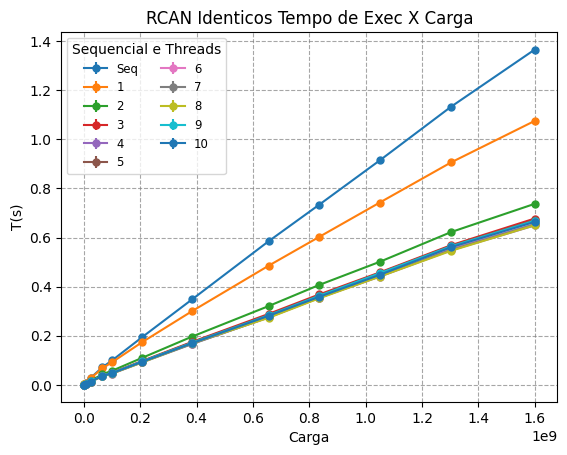

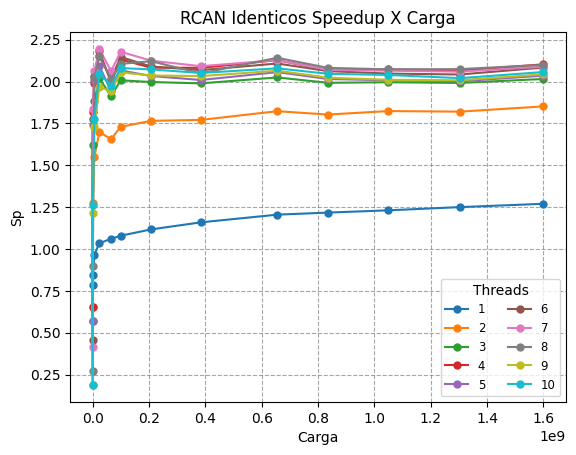

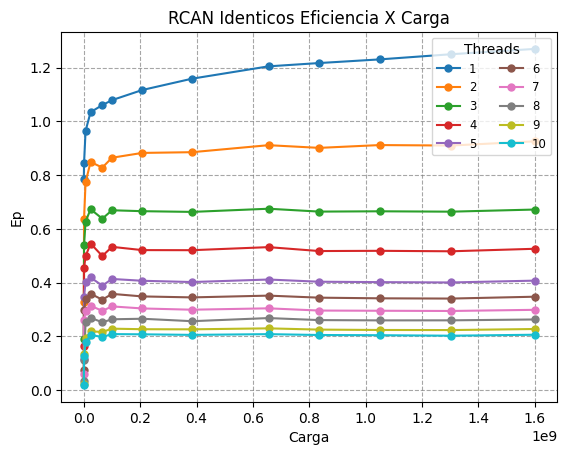

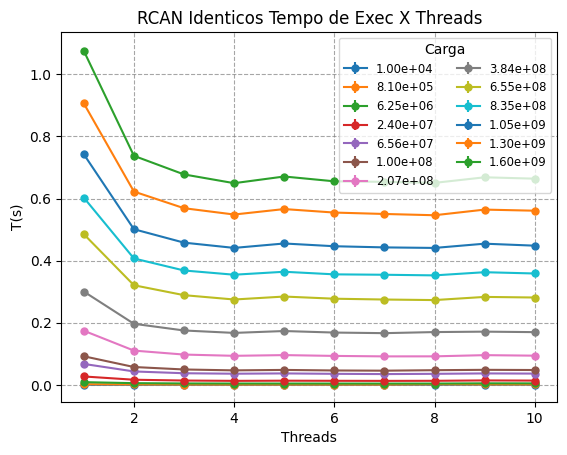

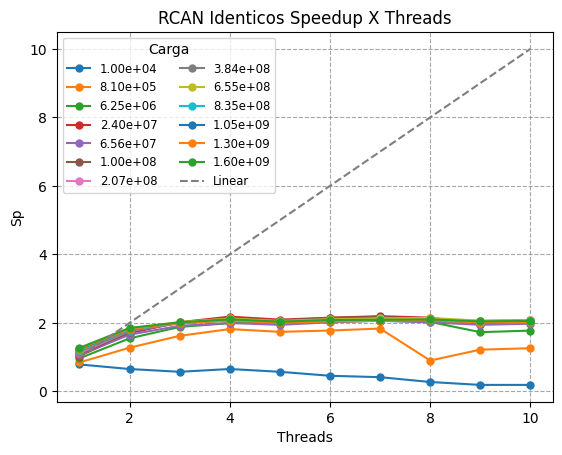

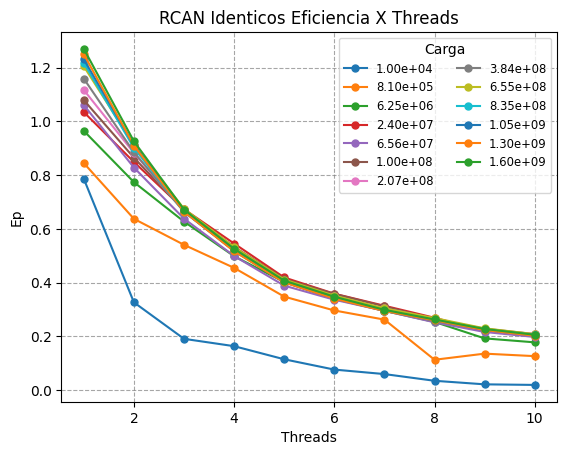

In [804]:
CSV_Path = "resultados.csv"
Tmax=10
seed=11
Casos_Seq, Casos_Par, Speedup_Par, Eficiencia_Par, Casos_Par_T, Speedup_Par_T, Eficiencia_Par_T, Totais = Work_Data(CSV_Path, Tmax, seed)
plot_Time_Load(Casos_Seq,Casos_Par,Tmax,Title="RCAN Identicos Tempo de Exec X Carga",save_fig=True)
plot_Speedup_Load(Speedup_Par,Tmax,Title="RCAN Identicos Speedup X Carga",save_fig=True)
plot_Eficiency_Load(Eficiencia_Par,Tmax,Title="RCAN Identicos Eficiencia X Carga",save_fig=True)
plot_Time_Threads(Casos_Par_T,Totais,Title="RCAN Identicos Tempo de Exec X Threads",save_fig=True)
plot_Speedup_Threads(Speedup_Par_T,Totais,Tmax,Title="RCAN Identicos Speedup X Threads",save_fig=True)
plot_Eficiency_Threads(Eficiencia_Par_T,Totais,Title="RCAN Identicos Eficiencia X Threads",save_fig=True)

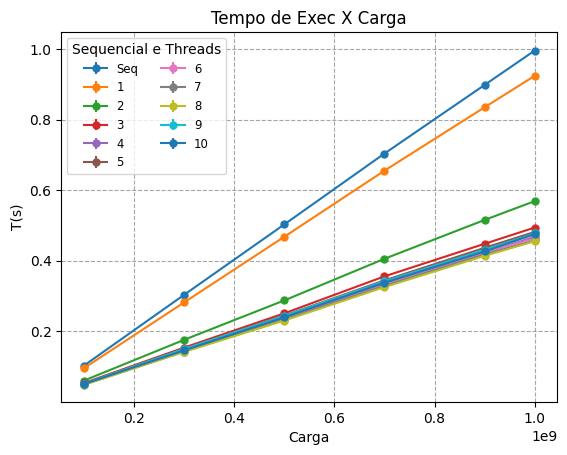

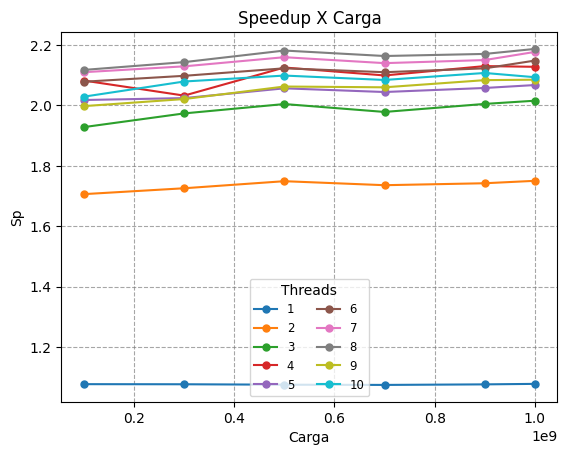

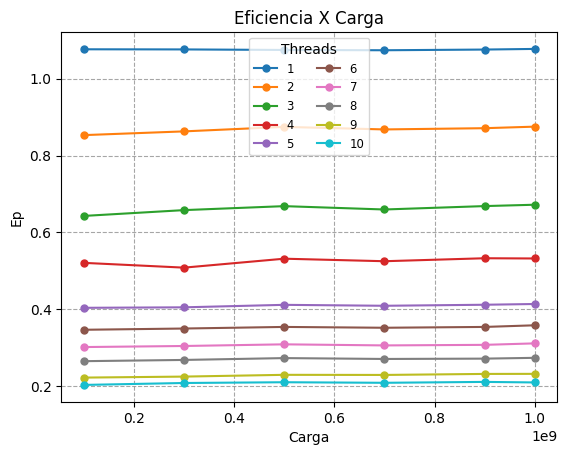

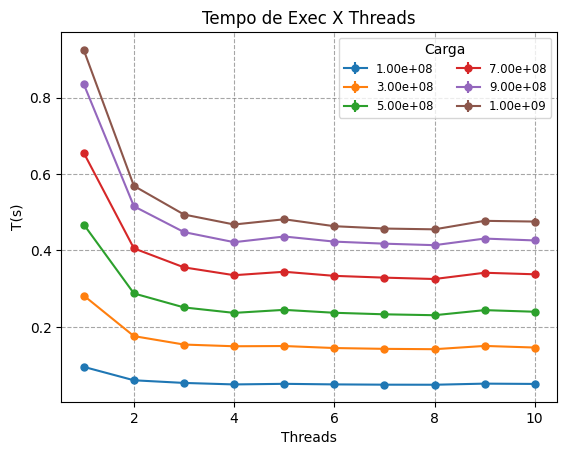

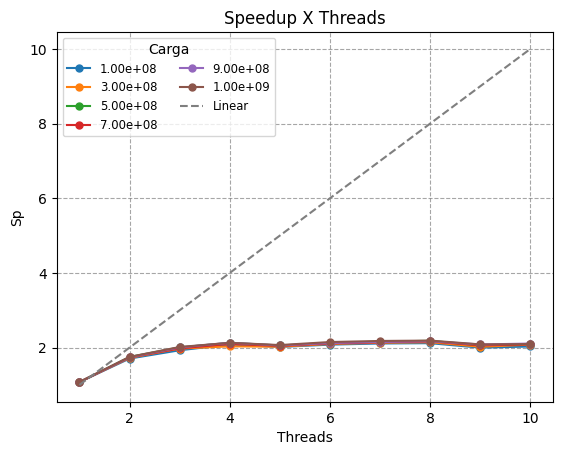

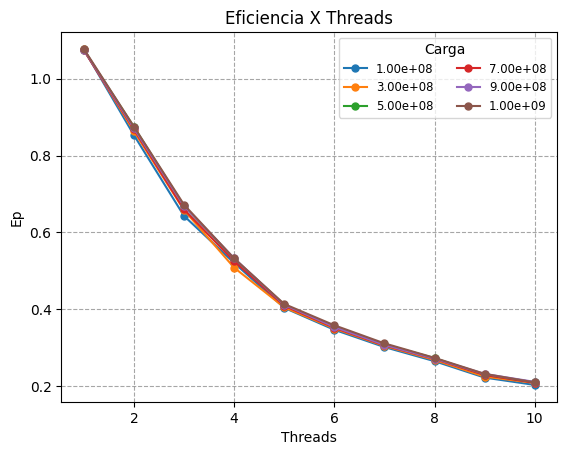

In [805]:
CSV_Path = "resultados.csv"
Tmax=10
seed=21
Casos_Seq, Casos_Par, Speedup_Par, Eficiencia_Par, Casos_Par_T, Speedup_Par_T, Eficiencia_Par_T, Totais = Work_Data(CSV_Path, Tmax, seed)
plot_Time_Load(Casos_Seq,Casos_Par,Tmax)
plot_Speedup_Load(Speedup_Par,Tmax)
plot_Eficiency_Load(Eficiencia_Par,Tmax)
plot_Time_Threads(Casos_Par_T,Totais)
plot_Speedup_Threads(Speedup_Par_T,Totais,Tmax)
plot_Eficiency_Threads(Eficiencia_Par_T,Totais)

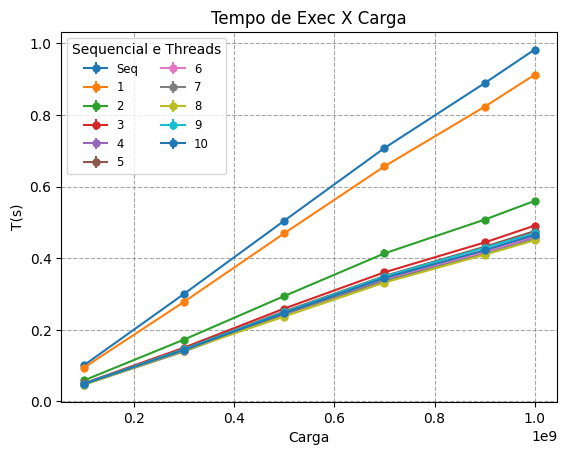

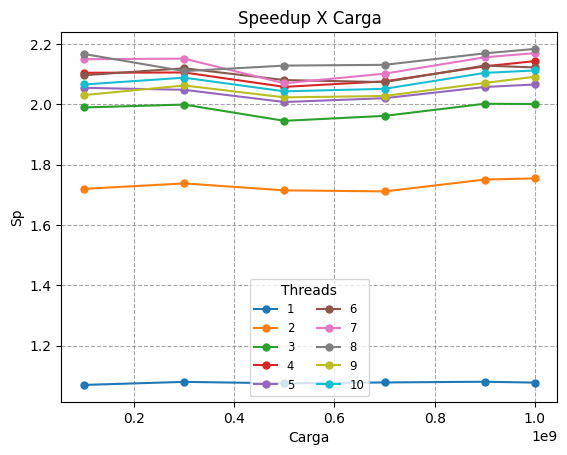

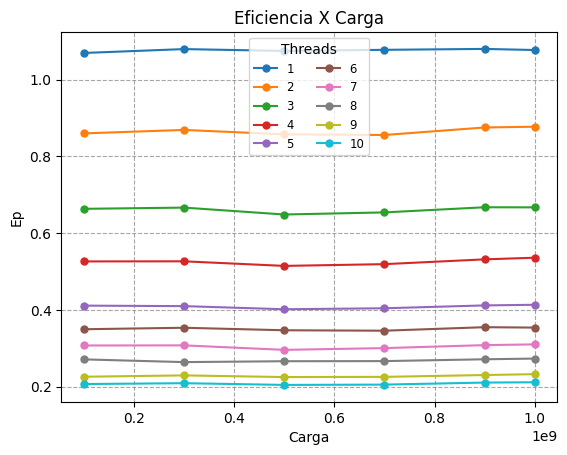

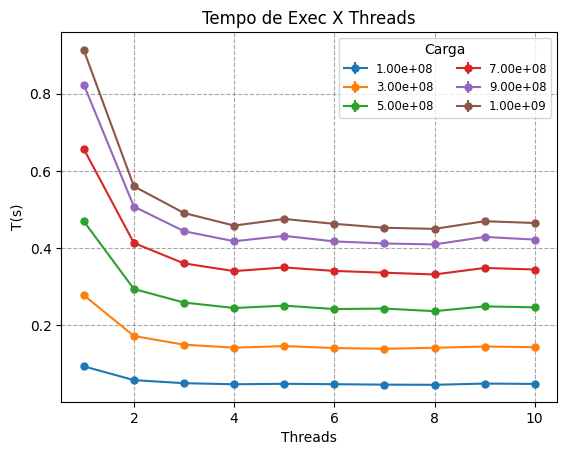

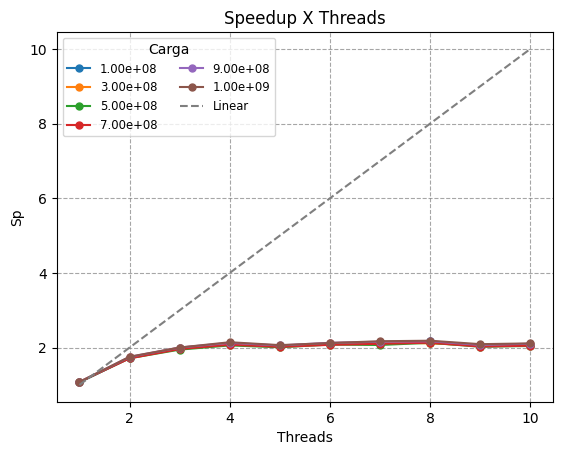

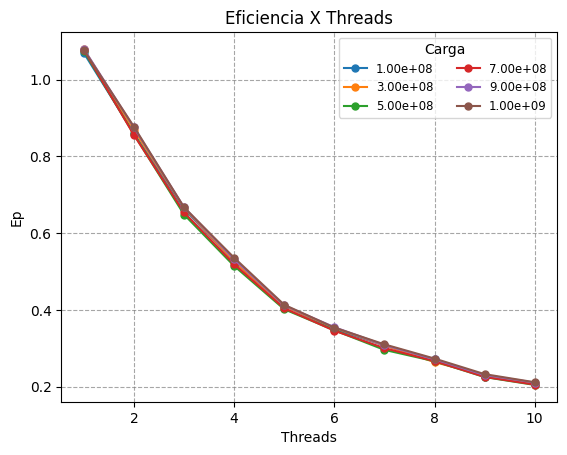

In [806]:
CSV_Path = "resultados.csv"
Tmax=10
seed=22
Casos_Seq, Casos_Par, Speedup_Par, Eficiencia_Par, Casos_Par_T, Speedup_Par_T, Eficiencia_Par_T, Totais = Work_Data(CSV_Path, Tmax, seed)
plot_Time_Load(Casos_Seq,Casos_Par,Tmax)
plot_Speedup_Load(Speedup_Par,Tmax)
plot_Eficiency_Load(Eficiencia_Par,Tmax)
plot_Time_Threads(Casos_Par_T,Totais)
plot_Speedup_Threads(Speedup_Par_T,Totais,Tmax)
plot_Eficiency_Threads(Eficiencia_Par_T,Totais)

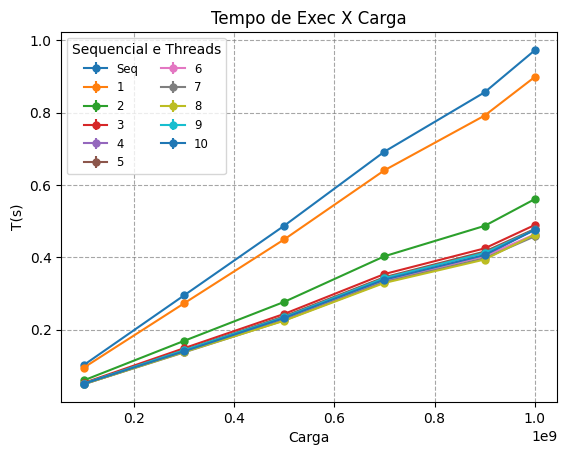

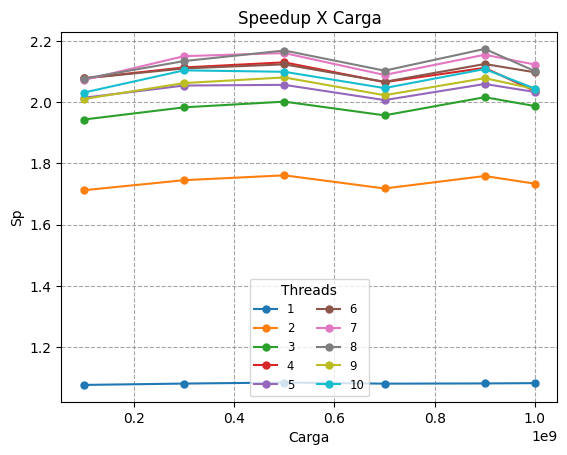

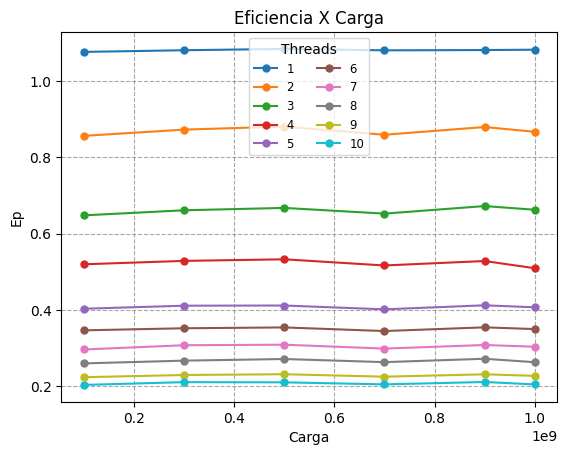

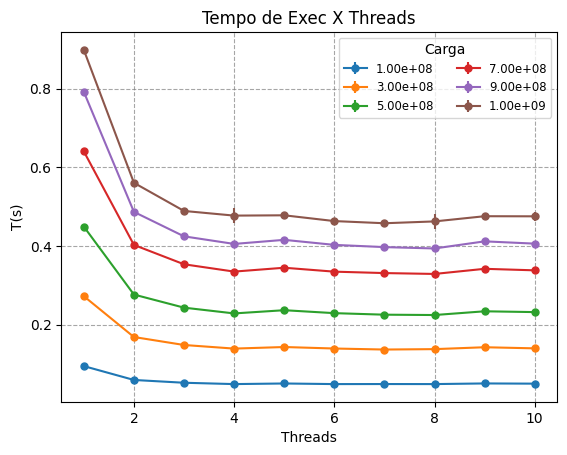

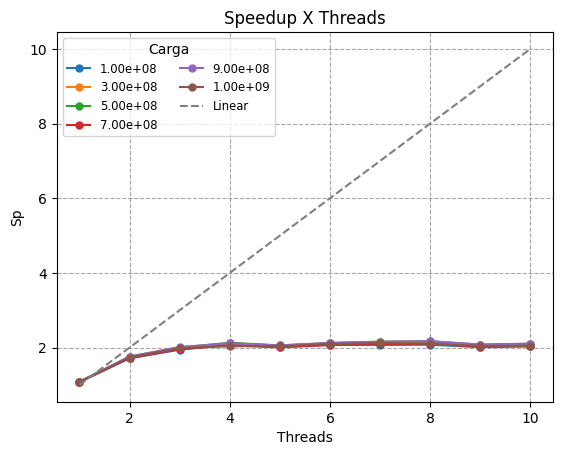

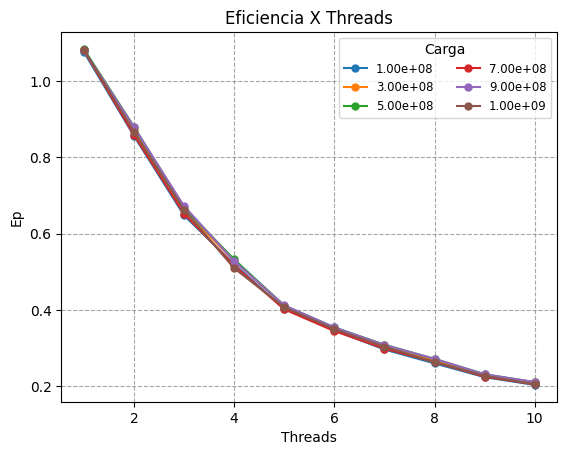

In [807]:
CSV_Path = "resultados.csv"
Tmax=10
seed=23
Casos_Seq, Casos_Par, Speedup_Par, Eficiencia_Par, Casos_Par_T, Speedup_Par_T, Eficiencia_Par_T, Totais = Work_Data(CSV_Path, Tmax, seed)
plot_Time_Load(Casos_Seq,Casos_Par,Tmax)
plot_Speedup_Load(Speedup_Par,Tmax)
plot_Eficiency_Load(Eficiencia_Par,Tmax)
plot_Time_Threads(Casos_Par_T,Totais)
plot_Speedup_Threads(Speedup_Par_T,Totais,Tmax)
plot_Eficiency_Threads(Eficiencia_Par_T,Totais)

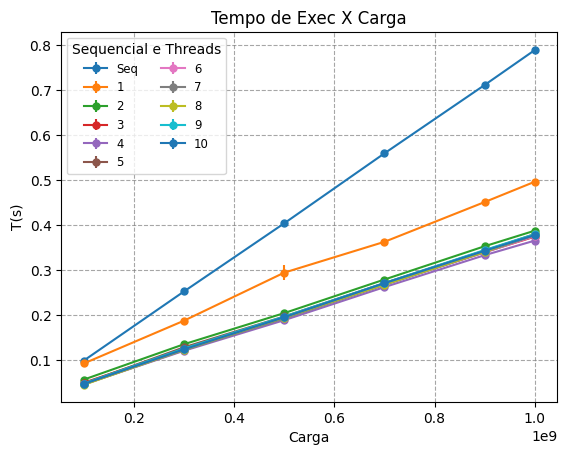

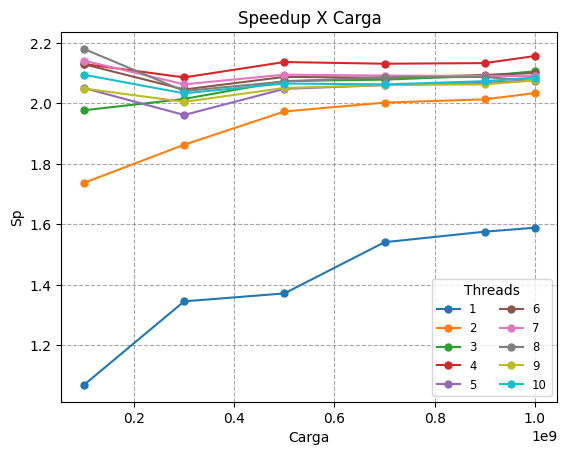

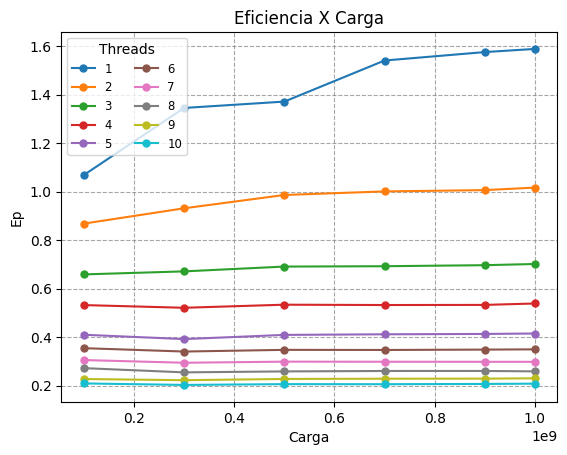

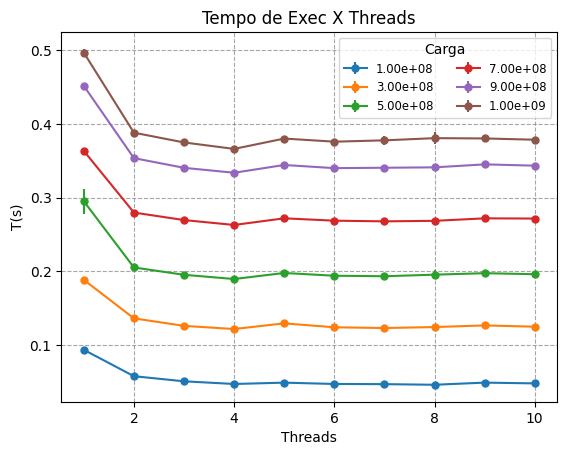

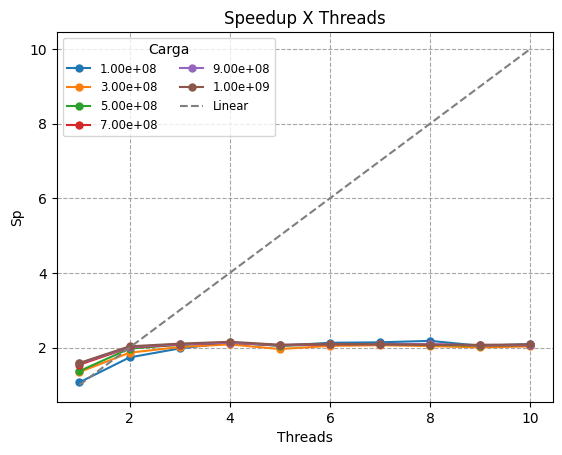

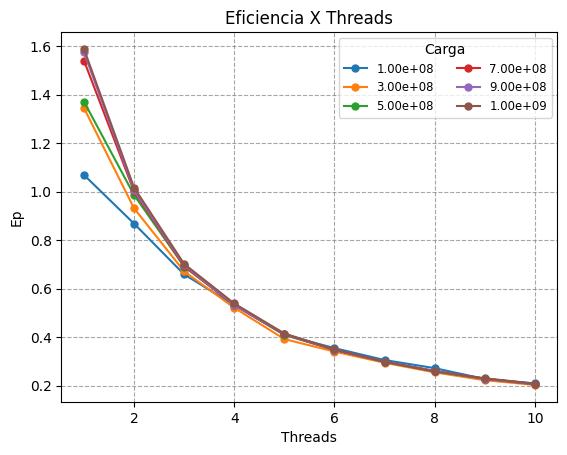

In [808]:
CSV_Path = "resultados.csv"
Tmax=10
seed=24
Casos_Seq, Casos_Par, Speedup_Par, Eficiencia_Par, Casos_Par_T, Speedup_Par_T, Eficiencia_Par_T, Totais = Work_Data(CSV_Path, Tmax, seed)
plot_Time_Load(Casos_Seq,Casos_Par,Tmax)
plot_Speedup_Load(Speedup_Par,Tmax)
plot_Eficiency_Load(Eficiencia_Par,Tmax)
plot_Time_Threads(Casos_Par_T,Totais)
plot_Speedup_Threads(Speedup_Par_T,Totais,Tmax)
plot_Eficiency_Threads(Eficiencia_Par_T,Totais)

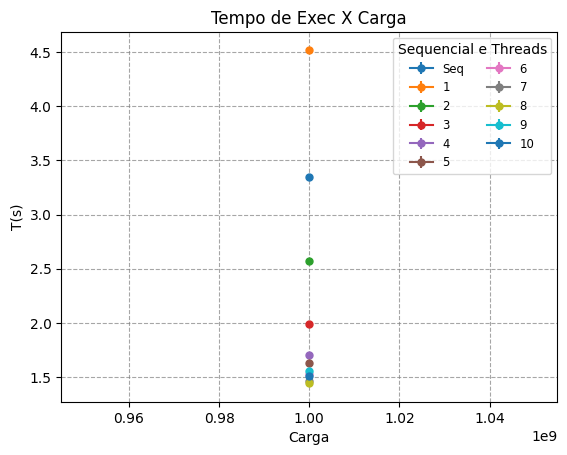

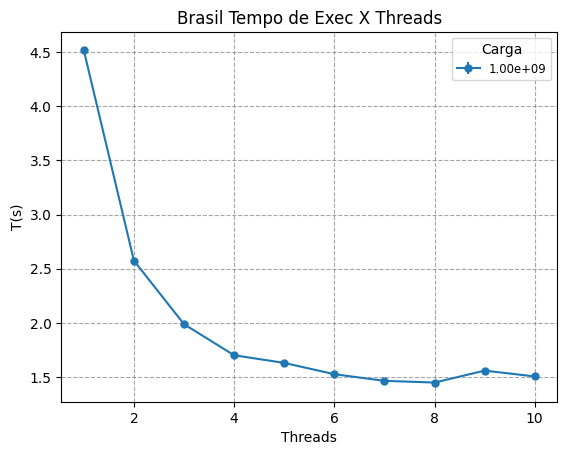

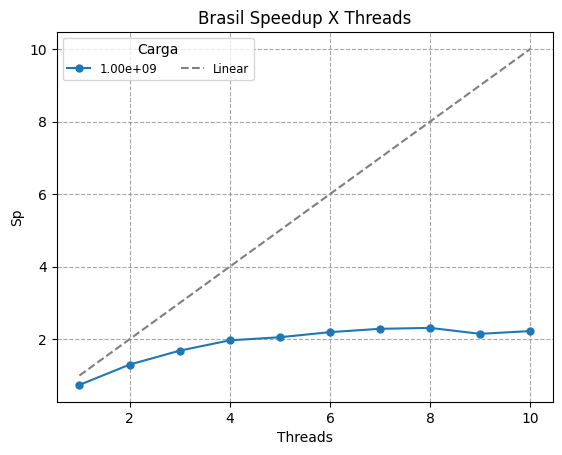

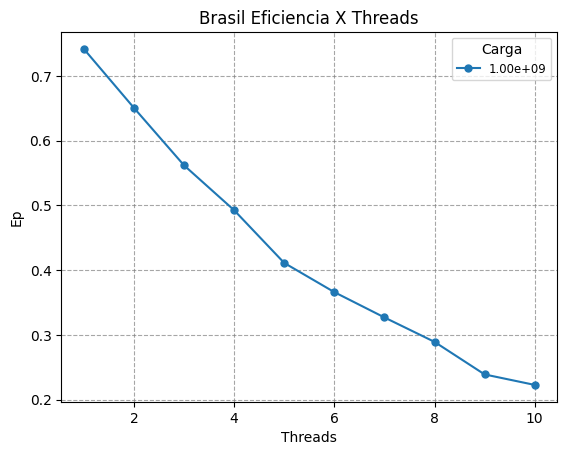

In [814]:
CSV_Path = "resultados.csv"
Tmax=10
seed=31
Casos_Seq, Casos_Par, Speedup_Par, Eficiencia_Par, Casos_Par_T, Speedup_Par_T, Eficiencia_Par_T, Totais = Work_Data(CSV_Path, Tmax, seed)
plot_Time_Load(Casos_Seq,Casos_Par,Tmax)
#plot_Speedup_Load(Speedup_Par,Tmax)
#plot_Eficiency_Load(Eficiencia_Par,Tmax)
plot_Time_Threads(Casos_Par_T,Totais, Title="Brasil Tempo de Exec X Threads", save_fig=True)
plot_Speedup_Threads(Speedup_Par_T,Totais,Tmax, Title="Brasil Speedup X Threads", save_fig=True)
plot_Eficiency_Threads(Eficiencia_Par_T,Totais,Title="Brasil Eficiencia X Threads", save_fig=True)

In [811]:
CSV_Path = "resultados.csv"
Tmax=10
seed=[41,42,43,44]
Tthreads = [1,2,3,4,5,6,7,8]
labels=[["R 10", "R 10000"],
        ["C 10", "C 10000"],
        ["A 10", "A 10000"],
        ["N 10", "N 10000"]]
markers=["o","v","s","p"]
n=2
df = pd.read_csv(CSV_Path)

Casos_Par_T, Speedup_Par_T, Eficiencia_Par_T, Totais = Work_Data_2(CSV_Path, Tmax, seed, Tthreads, n)


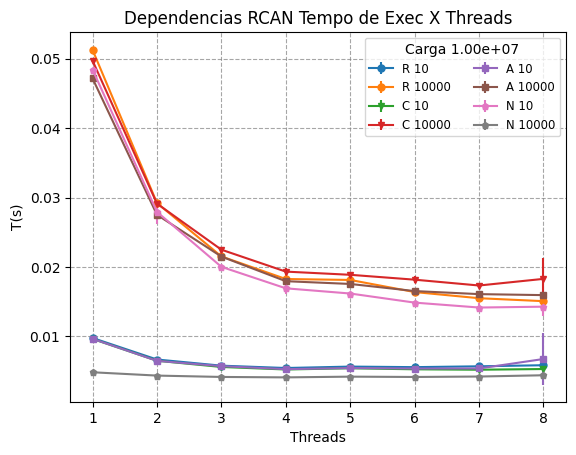

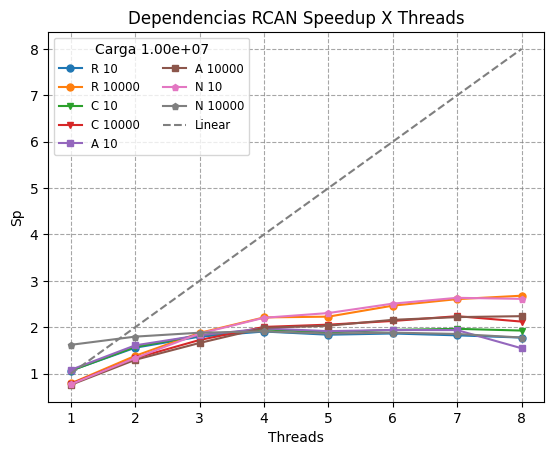

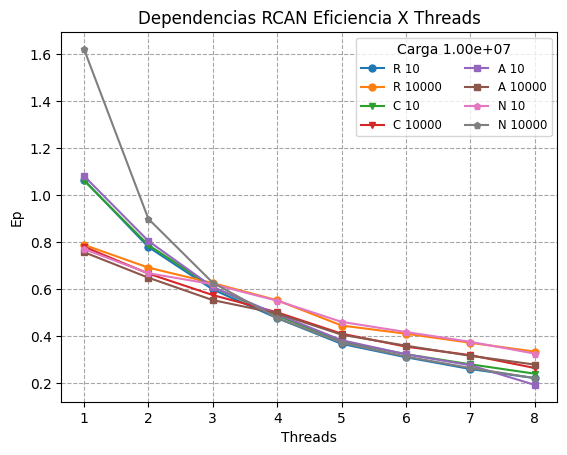

In [813]:
plot_Time_Threads_Isolation(Casos_Par_T,Totais,labels,markers,Title="Dependencias RCAN Tempo de Exec X Threads",save_fig=True)
plot_Speedup_Threads_Isolation(Speedup_Par_T,Totais,Tthreads[-1],labels,markers,Title="Dependencias RCAN Speedup X Threads",save_fig=True)
plot_Eficiency_Threads_Isolation(Eficiencia_Par_T,Totais,labels,markers,Title="Dependencias RCAN Eficiencia X Threads", save_fig=True)